# CatBoost Workspace

Отдельный ноутбук только для CatBoost.

Здесь используется изолированный модуль `model_baselines_catboost.py`, чтобы не тянуть Naive, ARIMA, SARIMA, N-BEATS и LSTM.

Поток работы:
1. загрузка и очистка данных,
2. настройка CatBoost и профиля поиска,
3. `HalvingGridSearchCV` + финальное обучение,
4. rolling 24h benchmark на minute-данных,
5. экспорт результатов.

## 1) Окружение

При необходимости раскомментируй установку пакетов и перезапусти kernel.

In [1]:
# %pip install pandas numpy requests statsmodels matplotlib seaborn scikit-learn torch tqdm catboost

import sys
print('Python:', sys.version)

Python: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]


## 2) Импорты и базовая конфигурация

Подключаем проект, включаем изолированный CatBoost-модуль и задаём общие параметры запуска.

In [2]:
import importlib

import os

from pathlib import Path

import numpy as np

import pandas as pd

import seaborn as sns

import torch

import data_pipeline as _dp

import model_baselines_catboost as _mb

import catboost_backtest as _cb_backtest

from export_utils import plot_result

_dp = importlib.reload(_dp)
_mb = importlib.reload(_mb)
_cb_backtest = importlib.reload(_cb_backtest)

DataConfig = _dp.DataConfig
DataProcessor = _dp.DataProcessor
build_datasets = _dp.build_datasets
load_klines_from_sqlite = _dp.load_klines_from_sqlite
load_market_snapshots_from_sqlite = _dp.load_market_snapshots_from_sqlite
sync_market_data_to_sqlite = _dp.sync_market_data_to_sqlite

run_catboost = _mb.run_catboost
run_catboost_gridsearchcv_native_pipeline = _mb.run_catboost_gridsearchcv_native_pipeline
fit_catboost_inference_model = _mb.fit_catboost_inference_model
predict_catboost_inference = _mb.predict_catboost_inference
fit_catboost_multi_horizon_inference_model = _mb.fit_catboost_multi_horizon_inference_model
predict_catboost_multi_horizon_path = _mb.predict_catboost_multi_horizon_path

forecast_catboost_path = _cb_backtest.forecast_catboost_path
calculate_forecast_path_diagnostics = _cb_backtest.calculate_forecast_path_diagnostics

CPU_COUNT = int(os.cpu_count() or 8)
SAFE_CPU_WORKERS = max(1, min(16, CPU_COUNT - 1))

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid')

CONFIG = DataConfig(
    base_url='https://api.bybit.com',
    interval='1',
    bars=100_000,
    target_col='close',
    date_col='timestamp',
    test_ratio=0.2,
)

SYMBOLS = ['BTCUSDT', 'ETHUSDT']

OUTPUT_DIR = Path('data/outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SQLITE_DB_PATH = Path('data/market_data.sqlite')

MARKET_SNAPSHOT_ROWS = 5

print('data_pipeline module file:', Path(_dp.__file__).resolve())
print('CatBoost module file:', Path(_mb.__file__).resolve())
print('catboost_backtest module file:', Path(_cb_backtest.__file__).resolve())
print('SQLite DB:', SQLITE_DB_PATH.resolve())
print('CUDA available:', torch.cuda.is_available())

if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

print('SAFE_CPU_WORKERS:', SAFE_CPU_WORKERS)
print(f'Data config: interval={CONFIG.interval}m | bars={CONFIG.bars:,}')


data_pipeline module file: C:\Users\zzz20\ModelLine\data_pipeline.py
CatBoost module file: C:\Users\zzz20\ModelLine\model_baselines_catboost.py
catboost_backtest module file: C:\Users\zzz20\ModelLine\catboost_backtest.py
SQLite DB: C:\Users\zzz20\ModelLine\data\market_data.sqlite
CUDA available: True
GPU: NVIDIA GeForce RTX 4080
SAFE_CPU_WORKERS: 16
Data config: interval=1m | bars=100,000


## 3) Загрузка, очистка и разбиение данных

Скачиваем или читаем локальные ряды, затем очищаем и строим `full/train/test`.

In [3]:
raw_data = {}
processor = DataProcessor(target_col=CONFIG.target_col, date_col=CONFIG.date_col)
cleaned_data = {}
reports = {}
latest_snapshot_rows = []

for symbol in SYMBOLS:
    try:
        synced_df, snapshot = sync_market_data_to_sqlite(
            symbol=symbol,
            config=CONFIG,
            db_path=SQLITE_DB_PATH,
            history_bars=CONFIG.bars,
            fetch_snapshot=True,
        )
        raw_data[symbol] = load_klines_from_sqlite(
            symbol=symbol,
            interval=CONFIG.interval,
            db_path=SQLITE_DB_PATH,
            limit=CONFIG.bars,
        )
        print(
            f'{symbol}: SQLite sync complete | history_rows={len(raw_data[symbol])} | '
            f'snapshot_ts={snapshot["snapshot_ts"] if snapshot is not None else "n/a"}'
        )
    except Exception as ex:
        cached_df = load_klines_from_sqlite(
            symbol=symbol,
            interval=CONFIG.interval,
            db_path=SQLITE_DB_PATH,
            limit=CONFIG.bars,
        )
        if len(cached_df) == 0:
            raise RuntimeError(
                f'{symbol}: не удалось синхронизировать данные в SQLite и в базе нет кэша. Ошибка: {ex}'
            )
        raw_data[symbol] = cached_df
        print(f'{symbol}: sync error ({ex}), использован SQLite cache rows={len(cached_df)}')

    snapshot_df = load_market_snapshots_from_sqlite(symbol=symbol, db_path=SQLITE_DB_PATH, limit=1)
    if len(snapshot_df) > 0:
        latest_snapshot_rows.append(snapshot_df.iloc[0].to_dict())

for symbol, df in raw_data.items():
    clean_df, rep = processor.process(df)
    cleaned_data[symbol] = clean_df
    reports[symbol] = rep
    print(
        f'{symbol}: before={rep["initial_rows"]} after={rep["final_rows"]} removed={rep["removed_total"]} '
        f'(zero/nonpos={rep["removed_nonpositive_or_zero"]}, outliers={rep["removed_outliers"]})'
    )

datasets = build_datasets(cleaned_data, target_col=CONFIG.target_col, test_ratio=CONFIG.test_ratio)
for symbol, data in datasets.items():
    print(f'{symbol}: full={len(data["full"])} train={len(data["train"])} test={len(data["test"])}')

LATEST_SNAPSHOT_DF = pd.DataFrame(latest_snapshot_rows)
if len(LATEST_SNAPSHOT_DF) > 0:
    LATEST_SNAPSHOT_DF['snapshot_ts'] = pd.to_datetime(LATEST_SNAPSHOT_DF['snapshot_ts'], utc=True)
    print('\nТекущий рынок из SQLite snapshot:')
    display(LATEST_SNAPSHOT_DF[['symbol', 'snapshot_ts', 'last_price', 'bid_price', 'ask_price', 'bid_size', 'ask_size', 'spread']])

cleaned_data['BTCUSDT'].head()

BTCUSDT: SQLite sync complete | history_rows=100000 | snapshot_ts=2026-03-16 22:21:25.717000+00:00
ETHUSDT: SQLite sync complete | history_rows=100000 | snapshot_ts=2026-03-16 22:21:27.936000+00:00
BTCUSDT: before=100000 after=99558 removed=442 (zero/nonpos=0, outliers=442)
ETHUSDT: before=100000 after=99385 removed=615 (zero/nonpos=0, outliers=615)
BTCUSDT: full=99558 train=79646 test=19912
ETHUSDT: full=99385 train=79508 test=19877

Текущий рынок из SQLite snapshot:


,symbol,snapshot_ts,last_price,bid_price,ask_price,bid_size,ask_size,spread
0,BTCUSDT,2026-03-16 22:21:25.717000+00:00,74684.00,74683.20,74683.30,2.191,7.462,0.10
1,ETHUSDT,2026-03-16 22:21:27.936000+00:00,2364.48,2364.22,2364.23,39.740,24.110,0.01


,start_ms,timestamp,open,high,low,close,volume,turnover
0,1767699720000,2026-01-06 11:42:00+00:00,93748.5,93748.6,93748.5,93748.6,2.702,2.533085e+05
1,1767699780000,2026-01-06 11:43:00+00:00,93748.6,93752.5,93747.8,93752.4,9.598,8.998123e+05
2,1767699840000,2026-01-06 11:44:00+00:00,93752.4,93760.2,93752.4,93760.1,11.685,1.095554e+06
3,1767699900000,2026-01-06 11:45:00+00:00,93760.1,93840.6,93760.1,93833.5,42.724,4.008101e+06
4,1767699960000,2026-01-06 11:46:00+00:00,93833.5,93833.5,93798.4,93800.5,10.493,9.843446e+05


## 4) Конфиг эксперимента CatBoost

Здесь меняются символ, профиль поиска, scoring и параметры rolling benchmark.

In [4]:
from sklearn.model_selection import ParameterGrid

RUN_SYMBOL = 'BTCUSDT'
RUN_MODEL = 'catboost'

CATBOOST_GRID_PROFILE = 'aggressive'  # aggressive profile is used as base
CATBOOST_SCORING = 'MAE'
CATBOOST_TIME_WEIGHT = 0.05

# Если torch не видит CUDA, но nvidia-smi доступна --- можем попробовать принудительно включить GPU для CatBoost.
if not torch.cuda.is_available():
    try:
        import subprocess
        subprocess.run(['nvidia-smi'], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL, check=True)
        os.environ.setdefault('CATBOOST_FORCE_GPU', '1')
        print('nvidia-smi обнаружена: будет предпринята попытка использования CatBoost GPU через CATBOOST_FORCE_GPU=1')
    except Exception:
        pass

# CatBoost GPU flag: prefer native CUDA if available, else allow forcing GPU via env var.
CATBOOST_USE_CUDA = bool(torch.cuda.is_available()) or os.getenv('CATBOOST_FORCE_GPU', '0').lower() in ('1', 'true', 'yes')
if not CATBOOST_USE_CUDA:
    print('CUDA не найдена (torch.cuda.is_available() == False). CatBoost будет работать на CPU.\n'
          'Чтобы попытаться запустить CatBoost на GPU, установите переменную окружения CATBOOST_FORCE_GPU=1.')

# Для GPU-подбора n_jobs=1 (одна тяжелая задача на одной GPU)
CATBOOST_GRID_N_JOBS = 1
CATBOOST_CV_SPLITS = 2
CATBOOST_HALVING_FACTOR = 4
CATBOOST_SEARCH_MIN_POINTS = 512
CATBOOST_SEARCH_MAX_POINTS = 2_048  # reduce halving stages for faster search
CATBOOST_TUNING_POINTS = 16_384  # последние N точек только для подбора; финальная модель ниже обучается на полном train

LIVE_MONITOR_ENABLED = False
LIVE_TRAIN_MINUTES = 40_000
LIVE_FORECAST_HORIZON_MINUTES = 360
LIVE_RETRAIN_EVERY_MINUTES = 60
LIVE_SYNC_BUFFER = 240
LIVE_POLL_SECONDS = 60
LIVE_MAX_CYCLES = None  # None = endless loop until interrupted manually
LIVE_FORCE_CPU = False

# Trading fee config. Percent values are expressed in pct units, not fractions.
LIVE_MARKET_TYPE = 'perpetual_futures'  # spot | perpetual_futures | options
LIVE_FEE_SCHEDULES = {
    'spot': {'taker_pct': 0.10, 'maker_pct': 0.10},
    'perpetual_futures': {'taker_pct': 0.06, 'maker_pct': 0.01},
    'options': {'taker_pct': 0.03, 'maker_pct': 0.03},
}
if LIVE_MARKET_TYPE not in LIVE_FEE_SCHEDULES:
    raise ValueError(f'Unknown LIVE_MARKET_TYPE: {LIVE_MARKET_TYPE}')
LIVE_FEE_CONFIG = LIVE_FEE_SCHEDULES[LIVE_MARKET_TYPE]
LIVE_MAX_SIDE_FEE_PCT = float(max(LIVE_FEE_CONFIG['taker_pct'], LIVE_FEE_CONFIG['maker_pct']))
LIVE_ROUND_TRIP_COST_PCT = float(LIVE_MAX_SIDE_FEE_PCT * 2.0)  # max fee on entry + max fee on exit
LIVE_MIN_EDGE_PCT = 0.08         # minimum net edge after costs to allow entry
LIVE_CONFIRM_1M_PCT = 0.01       # 1-minute forecast must confirm direction
LIVE_STOP_LOSS_PCT = 0.35
LIVE_TAKE_PROFIT_PCT = 0.60
LIVE_SIGNAL_HORIZONS = [1, 5, 10, 15, 30, 60]
LIVE_PULLBACK_ENTRY_PCT = 0.03   # short-term pullback magnitude before recovery
LIVE_REVERSAL_CONFIRM_PCT = 0.05 # medium horizon must reverse enough to treat as dip/rally entry
LIVE_ENTRY_MIN_MOVE_PCT = 0.03   # минимальный модуль 60m-прогноза, ниже которого вход не рассматривается
LIVE_ENTRY_RELATIVE_STRENGTH = 0.75  # адаптивный порог как доля от типичного масштаба прогнозов 10m/30m/60m
LIVE_EFFECTIVE_COST_CAP_RATIO = 0.50  # для слабых моделей не учитывать в signal gate весь round-trip cost целиком
LIVE_PULLBACK_FRACTION_OF_REQUIRED = 0.50  # pullback-порог как доля от адаптивного required_move
LIVE_REVERSAL_FRACTION_OF_REQUIRED = 0.50  # reversal-порог как доля от адаптивного required_move

PAPER_TRADING_ENABLED = True
PAPER_LEVERAGE = 1.0
PAPER_INITIAL_CAPITAL = 10_000.0
PAPER_ENTRY_FRACTION = 0.10
PAPER_DCA_FRACTION = 0.10
PAPER_MAX_DCA_COUNT = 3
PAPER_DCA_STEP_PCT = 0.20
PAPER_CLOSE_ON_SIGNAL_FLIP = True
PAPER_CLOSE_ON_MODEL_EXPIRY = True

train = datasets[RUN_SYMBOL]['train']
test = datasets[RUN_SYMBOL]['test']
full = datasets[RUN_SYMBOL]['full']

if CATBOOST_TUNING_POINTS is None or int(CATBOOST_TUNING_POINTS) <= 0:
    tuning_full = full.reset_index(drop=True)
else:
    tuning_full = full.iloc[-min(len(full), int(CATBOOST_TUNING_POINTS)):].reset_index(drop=True)

ALL_RESULTS = {}
TRAINED_MODELS = {}

def _compute_signal_thresholds(horizon_forecasts: dict[str, float]) -> dict[str, float]:
    scale_values = [
        abs(float(horizon_forecasts.get(f'move_{int(horizon)}m_pct', float('nan'))))
        for horizon in [10, 30, 60]
    ]
    scale_values = [value for value in scale_values if np.isfinite(value)]

    forecast_scale_pct = float(np.median(scale_values)) if len(scale_values) > 0 else 0.0
    required_move_pct = float(max(LIVE_ENTRY_MIN_MOVE_PCT, forecast_scale_pct * LIVE_ENTRY_RELATIVE_STRENGTH))
    effective_cost_pct = float(min(LIVE_ROUND_TRIP_COST_PCT, required_move_pct * LIVE_EFFECTIVE_COST_CAP_RATIO))
    entry_trigger_move_pct = float(max(required_move_pct, effective_cost_pct))
    adaptive_pullback_pct = float(max(LIVE_PULLBACK_ENTRY_PCT * 0.50, required_move_pct * LIVE_PULLBACK_FRACTION_OF_REQUIRED))
    adaptive_reversal_pct = float(max(LIVE_CONFIRM_1M_PCT, min(LIVE_REVERSAL_CONFIRM_PCT, required_move_pct * LIVE_REVERSAL_FRACTION_OF_REQUIRED)))

    return {
        'forecast_scale_pct': forecast_scale_pct,
        'required_move_pct': required_move_pct,
        'effective_cost_pct': effective_cost_pct,
        'entry_trigger_move_pct': entry_trigger_move_pct,
        'adaptive_pullback_pct': adaptive_pullback_pct,
        'adaptive_reversal_pct': adaptive_reversal_pct,
    }

def _build_catboost_full_values_grid(full_values: dict, use_cuda_flag: bool) -> list[dict]:
    return [{**full_values, 'use_cuda': [use_cuda_flag]}]

GRID_PROFILES = {
    'aggressive': _build_catboost_full_values_grid(
        full_values={
            # Shrunk grid: 48 candidates total, halving now usually ~120 fits (close to requested ~100)
            'context_len': [120, 240],
            'depth': [8, 12],
            'learning_rate': [0.03, 0.10],
            'iterations': [600, 1000, 1800],
            'l2_leaf_reg': [0.5, 2.0],
        },
        use_cuda_flag=CATBOOST_USE_CUDA,
    ),
}

if CATBOOST_GRID_PROFILE not in GRID_PROFILES:
    raise ValueError(f'Unknown CATBOOST_GRID_PROFILE: {CATBOOST_GRID_PROFILE}')

CATBOOST_PARAM_GRID = GRID_PROFILES[CATBOOST_GRID_PROFILE]
CATBOOST_PARAM_GRID_CANDIDATES = len(ParameterGrid(CATBOOST_PARAM_GRID))

print(f'RUN_SYMBOL={RUN_SYMBOL} | full={len(full)} | tuning_full={len(tuning_full)} | final_train={len(train)} | final_test={len(test)}')
print(f'CatBoost grid profile: {CATBOOST_GRID_PROFILE} (single aggressive block)')
print('CatBoost device:', torch.cuda.get_device_name(0))
print(
    f'CatBoost config: use_cuda={CATBOOST_USE_CUDA}, n_jobs={CATBOOST_GRID_N_JOBS}, ' +
    f'cv_splits={CATBOOST_CV_SPLITS}, candidates={CATBOOST_PARAM_GRID_CANDIDATES}'
)
print(
    f'CatBoost search: tuning_points={len(tuning_full)}, min_points={CATBOOST_SEARCH_MIN_POINTS}, ' +
    f'max_points={CATBOOST_SEARCH_MAX_POINTS}, factor={CATBOOST_HALVING_FACTOR}, ' +
    f'scoring={CATBOOST_SCORING}, time_weight={CATBOOST_TIME_WEIGHT}'
)
print(
    f'Live config: enabled={LIVE_MONITOR_ENABLED}, train_minutes={LIVE_TRAIN_MINUTES}, horizon_minutes={LIVE_FORECAST_HORIZON_MINUTES}, ' +
    f'retrain_every={LIVE_RETRAIN_EVERY_MINUTES}, poll_seconds={LIVE_POLL_SECONDS}, max_cycles={LIVE_MAX_CYCLES}'
)
print(
    f'Trading config: market_type={LIVE_MARKET_TYPE}, max_side_fee_pct={LIVE_MAX_SIDE_FEE_PCT}, ' +
    f'round_trip_cost_pct={LIVE_ROUND_TRIP_COST_PCT}, min_edge_pct={LIVE_MIN_EDGE_PCT}, ' +
    f'entry_min_move_pct={LIVE_ENTRY_MIN_MOVE_PCT}, confirm_1m_pct={LIVE_CONFIRM_1M_PCT}, ' +
    f'stop_loss_pct={LIVE_STOP_LOSS_PCT}, take_profit_pct={LIVE_TAKE_PROFIT_PCT}'
)
print(
    f'Signal horizons={LIVE_SIGNAL_HORIZONS}, pullback_entry_pct={LIVE_PULLBACK_ENTRY_PCT}, ' +
    f'reversal_confirm_pct={LIVE_REVERSAL_CONFIRM_PCT}, entry_relative_strength={LIVE_ENTRY_RELATIVE_STRENGTH}, ' +
    f'effective_cost_cap_ratio={LIVE_EFFECTIVE_COST_CAP_RATIO}'
)
print(
    f'Paper trading: enabled={PAPER_TRADING_ENABLED}, leverage={PAPER_LEVERAGE}, initial_capital={PAPER_INITIAL_CAPITAL}, ' +
    f'entry_fraction={PAPER_ENTRY_FRACTION}, dca_fraction={PAPER_DCA_FRACTION}, ' +
    f'max_dca={PAPER_MAX_DCA_COUNT}, dca_step_pct={PAPER_DCA_STEP_PCT}'
)
CATBOOST_PARAM_GRID

RUN_SYMBOL=BTCUSDT | full=99558 | tuning_full=16384 | final_train=79646 | final_test=19912
CatBoost grid profile: aggressive (single aggressive block)
CatBoost device: NVIDIA GeForce RTX 4080
CatBoost config: use_cuda=True, n_jobs=1, cv_splits=2, candidates=48
CatBoost search: tuning_points=16384, min_points=512, max_points=2048, factor=4, scoring=MAE, time_weight=0.05
Live config: enabled=False, train_minutes=40000, horizon_minutes=360, retrain_every=60, poll_seconds=60, max_cycles=None
Trading config: market_type=perpetual_futures, max_side_fee_pct=0.06, round_trip_cost_pct=0.12, min_edge_pct=0.08, entry_min_move_pct=0.03, confirm_1m_pct=0.01, stop_loss_pct=0.35, take_profit_pct=0.6
Signal horizons=[1, 5, 10, 15, 30, 60], pullback_entry_pct=0.03, reversal_confirm_pct=0.05, entry_relative_strength=0.75, effective_cost_cap_ratio=0.5
Paper trading: enabled=True, leverage=1.0, initial_capital=10000.0, entry_fraction=0.1, dca_fraction=0.1, max_dca=3, dca_step_pct=0.2


[{'context_len': [120, 240],
  'depth': [8, 12],
  'learning_rate': [0.03, 0.1],
  'iterations': [600, 1000, 1800],
  'l2_leaf_reg': [0.5, 2.0],
  'use_cuda': [True]}]

## 5) Подбор гиперпараметров, финальное обучение и recursive-прогноз

Запускаем `HalvingGridSearchCV`, сохраняем лучшую конфигурацию и обучаем inference-модель CatBoost.

Затем сразу строим **recursive прогноз** на `180` минут вперёд — каузальный (без look-ahead):
каждый следующий шаг подаёт собственное предсказание обратно в контекст.
Именно этот режим используется в backtest (ячейка 14) и в live.


In [5]:
import json

CATBOOST_PARAMS_CACHE_ENABLED = True
CATBOOST_FORCE_RECOMPUTE_BEST_PARAMS = False
CATBOOST_PARAMS_CACHE_FILE = OUTPUT_DIR / f"{RUN_SYMBOL}_catboost_best_params_{CATBOOST_GRID_PROFILE}.json"

# HalvingGridSearchCV score cache (resume support):
# stores per-fold score results by hash(train/test slice + params).
CATBOOST_SCORE_CACHE_ENABLED = True
CATBOOST_SCORE_CACHE_DIR = OUTPUT_DIR / 'catboost_halving_score_cache'

print(f'CatBoost params cache file: {CATBOOST_PARAMS_CACHE_FILE.resolve()}')
print(f'Cache enabled: {CATBOOST_PARAMS_CACHE_ENABLED} | Force recompute: {CATBOOST_FORCE_RECOMPUTE_BEST_PARAMS}')
print(f'CV score cache: enabled={CATBOOST_SCORE_CACHE_ENABLED} | dir={CATBOOST_SCORE_CACHE_DIR.resolve()}')

CatBoost params cache file: C:\Users\zzz20\ModelLine\data\outputs\BTCUSDT_catboost_best_params_aggressive.json
Cache enabled: True | Force recompute: False
CV score cache: enabled=True | dir=C:\Users\zzz20\ModelLine\data\outputs\catboost_halving_score_cache


CatBoost params cache HIT: C:\Users\zzz20\ModelLine\data\outputs\BTCUSDT_catboost_best_params_aggressive.json
Grid search skipped because cached params were found.

[Model 1] Training recursive CatBoost (1-step)...
CatBoost: using GPU (task_type=GPU)
[Model 1] Training complete.
CatBoost tuning points: 16384
CatBoost final inference train points: 79646
CatBoost split info: {'cache_hit': True, 'cache_file': 'data\\outputs\\BTCUSDT_catboost_best_params_aggressive.json', 'cache_saved_at_utc': '2026-03-16T02:58:47.238043+00:00', 'search_skipped': True, 'test_ratio': 0.2, 'tuning_points': 16384}
CatBoost best params: {'context_len': 240, 'depth': 12, 'iterations': 600, 'l2_leaf_reg': 2.0, 'learning_rate': 0.03, 'use_cuda': True}
CatBoost metrics (1-step): {'MAE': 36.442110672442666, 'RMSE': 53.28252586975014, 'MAPE': 0.05196767954857891}
Demo settings: plots=True, recursive_use_cuda=True, direct_use_cuda=True, direct_iter_scale=0.25


,param_context_len,param_depth,param_learning_rate,param_iterations,param_l2_leaf_reg,cache_hit,cached_at_utc
0,240,12,0.03,600,2.0,True,2026-03-16T02:58:47.238043+00:00


,y_true,y_pred
0,68804.4,68797.849502
1,68928.1,68803.515940
2,68956.0,68930.287769
3,68877.6,68955.194891
4,68872.4,68878.576025


,y_true,y_pred
19907,74786.8,74860.779453
19908,74846.3,74792.399029
19909,74844.5,74851.051642
19910,74767.2,74836.375422
19911,74687.5,74776.571346


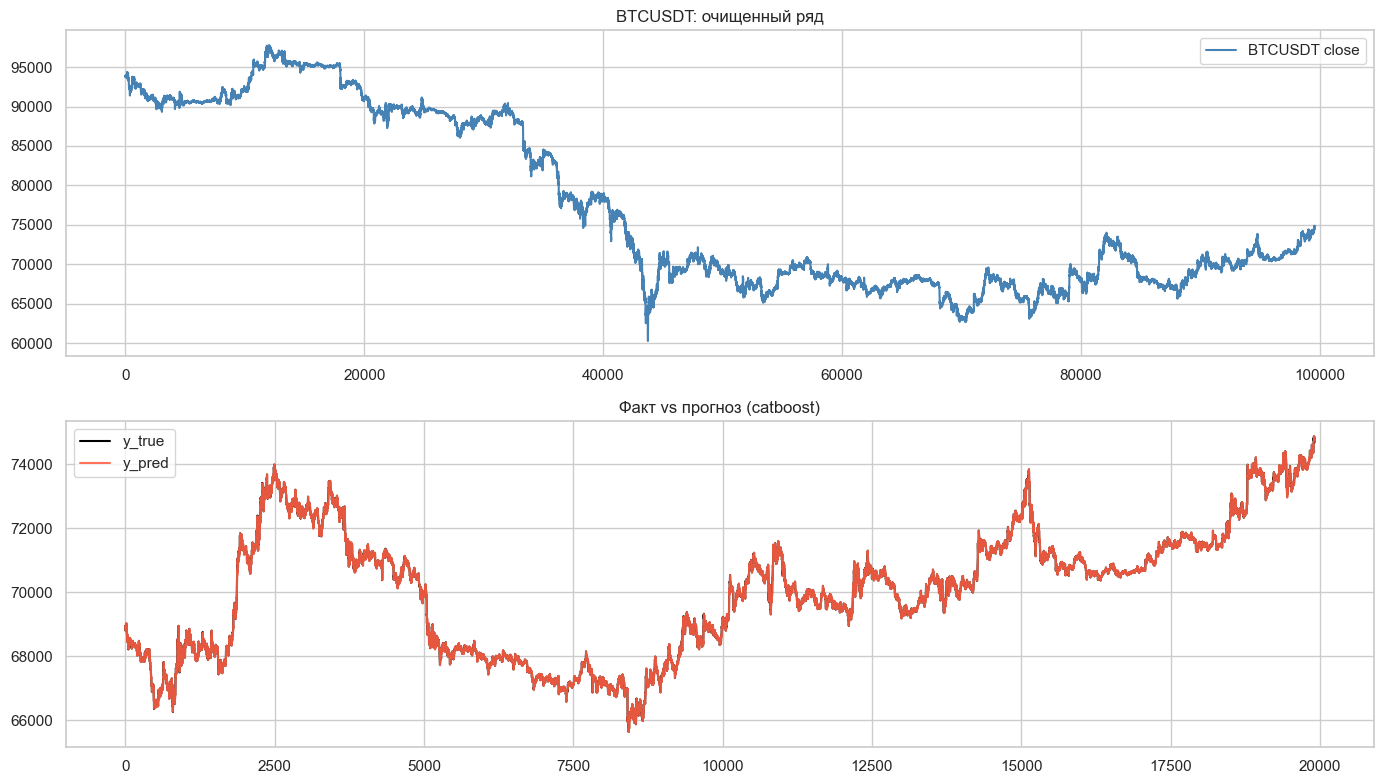


[Model 2] Training direct multi-horizon CatBoost | horizons=[1, 5, 10, 15, 30, 60, 120, 180, 240, 300, 360] | iterations=250...
CatBoost: using GPU (task_type=GPU)
CatBoost: using GPU (task_type=GPU)
CatBoost: using GPU (task_type=GPU)
CatBoost: using GPU (task_type=GPU)
CatBoost: using GPU (task_type=GPU)
CatBoost: using GPU (task_type=GPU)
CatBoost: using GPU (task_type=GPU)
CatBoost: using GPU (task_type=GPU)
CatBoost: using GPU (task_type=GPU)
CatBoost: using GPU (task_type=GPU)
CatBoost: using GPU (task_type=GPU)
[Model 2] Trained. Horizons: [1, 5, 10, 15, 30, 60, 120, 180, 240, 300, 360]

--- [Model 1] Recursive forecast | horizon=360m ---
  end_move:   -0.0173%
  path_span:  0.0680%
  ret_std:    0.000021
  accel_std:  0.000032
  linearity:  1.5036
  near_linear:False
  MAE@360m:  530.9270
  MAPE@360m: 0.7791%

Мульти-горизонтальное сравнение: Model 1 (Recursive) vs Model 2 (Direct):


,horizon_min,points,recursive_mae,recursive_mape_pct,recursive_pred_end,direct_mae,direct_mape_pct,direct_pred_end,actual_end
0,1,1,6.550498,0.009520,68797.849502,5.455642,0.007929,68798.944358,68804.4
1,5,5,92.151221,0.133713,68792.709312,91.714999,0.133079,68793.025707,68872.4
2,10,10,105.913312,0.153667,68805.593625,108.020367,0.156724,68804.540229,68920.2
3,15,15,118.804139,0.172324,68797.259799,120.542258,0.174846,68794.596638,68836.2
4,30,30,104.049742,0.151036,68801.841262,106.443017,0.154506,68798.269859,68590.0
5,60,60,210.672102,0.307305,68802.859131,203.368031,0.296620,68770.013379,68415.9
6,120,120,296.615434,0.433336,68769.822807,285.092587,0.416495,68777.397963,68322.1
7,180,180,335.558422,0.490521,68782.626873,330.936500,0.483770,68781.112154,68332.6
8,240,240,391.550641,0.572999,68791.970502,369.220131,0.540302,68645.848653,68259.5
9,300,300,481.842884,0.706583,68791.203675,441.386430,0.647182,68710.684205,67850.3


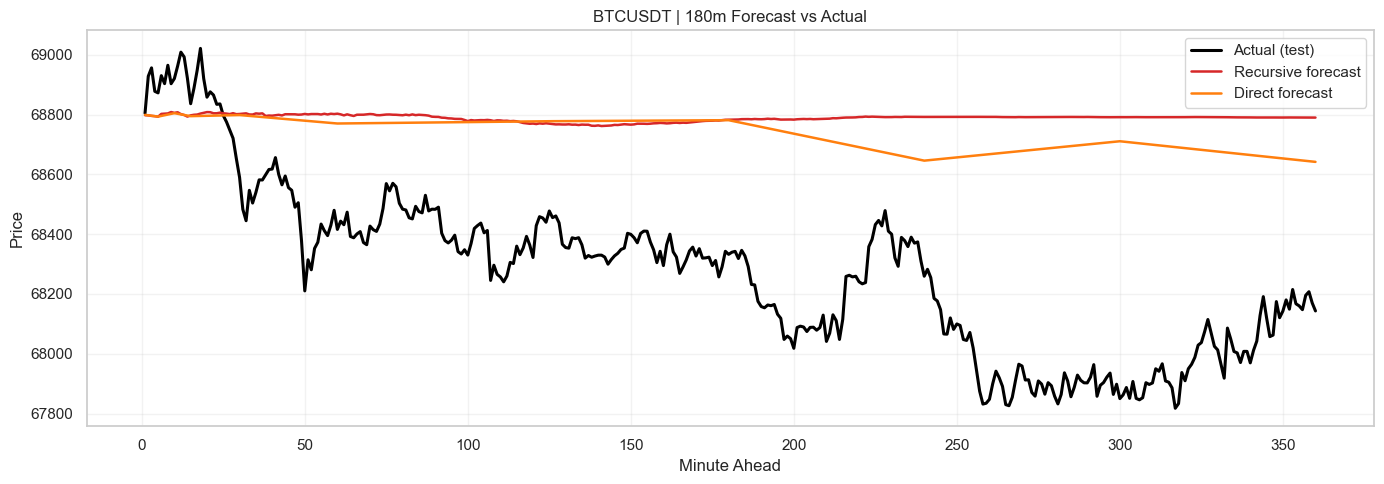


Recursive path (first 20 steps):


,step_minute,pred_price
0,1,68797.849502
1,2,68797.169690
2,3,68795.441625
3,4,68794.573765
4,5,68792.709312
5,6,68802.155366
6,7,68803.107847
7,8,68803.708709
8,9,68808.357437
9,10,68805.593625


In [6]:
import gc
import json
import matplotlib.pyplot as plt

cache_file = Path(CATBOOST_PARAMS_CACHE_FILE)
force_recompute = bool(CATBOOST_FORCE_RECOMPUTE_BEST_PARAMS)
cache_enabled = bool(CATBOOST_PARAMS_CACHE_ENABLED)

# Anti-crash knobs for heavy demo cell (CUDA retained)
CATBOOST_DEMO_ENABLE_PLOTS = True
CATBOOST_RECURSIVE_USE_CUDA = True
CATBOOST_MH_USE_CUDA = True
CATBOOST_MH_ITER_SCALE = 0.25

cache_hit = cache_enabled and cache_file.exists() and not force_recompute

if cache_hit:
    with cache_file.open('r', encoding='utf-8') as f:
        cached_payload = json.load(f)

    catboost_best_params = dict(cached_payload['best_params'])
    catboost_best_params['context_len'] = int(catboost_best_params['context_len'])
    catboost_best_params['depth'] = int(catboost_best_params['depth'])
    catboost_best_params['learning_rate'] = float(catboost_best_params['learning_rate'])
    catboost_best_params['iterations'] = int(catboost_best_params['iterations'])
    catboost_best_params['l2_leaf_reg'] = float(catboost_best_params.get('l2_leaf_reg', 3.0))
    catboost_best_params['use_cuda'] = bool(catboost_best_params.get('use_cuda', CATBOOST_USE_CUDA))

    catboost_cv_df = pd.DataFrame([
        {
            'cache_hit': True,
            'cached_at_utc': cached_payload.get('saved_at_utc'),
            'param_context_len': catboost_best_params['context_len'],
            'param_depth': catboost_best_params['depth'],
            'param_learning_rate': catboost_best_params['learning_rate'],
            'param_iterations': catboost_best_params['iterations'],
            'param_l2_leaf_reg': catboost_best_params['l2_leaf_reg'],
            'param_use_cuda': catboost_best_params['use_cuda'],
        }
    ])

    catboost_split_info = {
        'cache_hit': True,
        'cache_file': str(cache_file),
        'cache_saved_at_utc': cached_payload.get('saved_at_utc'),
        'search_skipped': True,
        'test_ratio': float(CONFIG.test_ratio),
        'tuning_points': int(len(tuning_full)),
    }

    print(f'CatBoost params cache HIT: {cache_file.resolve()}')
    print('Grid search skipped because cached params were found.')
else:
    catboost_best_params, catboost_cv_df, model_metrics, pred_df, catboost_split_info = run_catboost_gridsearchcv_native_pipeline(
        full_series=tuning_full,
        param_grid=CATBOOST_PARAM_GRID,
        test_ratio=CONFIG.test_ratio,
        n_splits=CATBOOST_CV_SPLITS,
        scoring=CATBOOST_SCORING,
        use_cuda=CATBOOST_USE_CUDA,
        n_jobs=CATBOOST_GRID_N_JOBS,
        min_resource_points=CATBOOST_SEARCH_MIN_POINTS,
        max_resource_points=CATBOOST_SEARCH_MAX_POINTS,
        halving_factor=CATBOOST_HALVING_FACTOR,
        aggressive_elimination=True,
        time_weight=CATBOOST_TIME_WEIGHT,
        score_cache_enabled=bool(CATBOOST_SCORE_CACHE_ENABLED),
        score_cache_dir=str(CATBOOST_SCORE_CACHE_DIR),
    )

    if cache_enabled:
        cache_file.parent.mkdir(parents=True, exist_ok=True)
        cache_payload = {
            'saved_at_utc': pd.Timestamp.now(tz='UTC').isoformat(),
            'symbol': RUN_SYMBOL,
            'grid_profile': CATBOOST_GRID_PROFILE,
            'scoring': CATBOOST_SCORING,
            'best_params': catboost_best_params,
        }
        with cache_file.open('w', encoding='utf-8') as f:
            json.dump(cache_payload, f, ensure_ascii=False, indent=2)
        print(f'CatBoost params cache saved: {cache_file.resolve()}')

# ── Модель 1: Recursive (1-step, iterative inference) ────────────────────────
print('\n[Model 1] Training recursive CatBoost (1-step)...')
TRAINED_MODELS[RUN_MODEL] = fit_catboost_inference_model(
    train,
    context_len=int(catboost_best_params['context_len']),
    depth=int(catboost_best_params['depth']),
    learning_rate=float(catboost_best_params['learning_rate']),
    iterations=int(catboost_best_params['iterations']),
    l2_leaf_reg=float(catboost_best_params.get('l2_leaf_reg', 3.0)),
    use_cuda=bool(CATBOOST_RECURSIVE_USE_CUDA),
)

model_metrics, pred_df = predict_catboost_inference(
    TRAINED_MODELS[RUN_MODEL],
    train=train,
    test=test,
)

ALL_RESULTS[RUN_MODEL] = {
    'metrics': model_metrics,
    'pred_df': pred_df.copy(),
    'symbol': RUN_SYMBOL,
}

cv_preview_cols = [
    col for col in [
        'score',
        'score_std',
        'param_context_len',
        'param_depth',
        'param_learning_rate',
        'param_iterations',
        'param_l2_leaf_reg',
        'iter',
        'rank_test_score',
        'cache_hit',
        'cached_at_utc',
    ] if col in catboost_cv_df.columns
]

print('[Model 1] Training complete.')
print('CatBoost tuning points:', len(tuning_full))
print('CatBoost final inference train points:', len(train))
print('CatBoost split info:', catboost_split_info)
print('CatBoost best params:', catboost_best_params)
print('CatBoost metrics (1-step):', model_metrics)
print(f'Demo settings: plots={CATBOOST_DEMO_ENABLE_PLOTS}, recursive_use_cuda={CATBOOST_RECURSIVE_USE_CUDA}, direct_use_cuda={CATBOOST_MH_USE_CUDA}, direct_iter_scale={CATBOOST_MH_ITER_SCALE}')
display(catboost_cv_df[cv_preview_cols].head(20) if cv_preview_cols else catboost_cv_df.head(20))
display(pred_df.head())
display(pred_df.tail())
if CATBOOST_DEMO_ENABLE_PLOTS:
    plot_result(RUN_SYMBOL, RUN_MODEL, full, pred_df)

# Release GPU cache between heavy stages
gc.collect()
if torch.cuda.is_available():
    try:
        torch.cuda.empty_cache()
    except Exception:
        pass

# ── Модель 2: Direct multi-horizon (отдельная CatBoost на каждый горизонт) ───
RECURSIVE_DEMO_HORIZON = 360
MULTI_HORIZON_MINUTES = [1, 5, 10, 15, 30, 60, 120, 180, 240, 300, 360]
mh_iterations = max(250, int(int(catboost_best_params['iterations']) * float(CATBOOST_MH_ITER_SCALE)))

print(f'\n[Model 2] Training direct multi-horizon CatBoost | horizons={MULTI_HORIZON_MINUTES} | iterations={mh_iterations}...')
TRAINED_MODELS['catboost_mh_direct'] = fit_catboost_multi_horizon_inference_model(
    train,
    horizons=tuple(MULTI_HORIZON_MINUTES),
    context_len=int(catboost_best_params['context_len']),
    depth=int(catboost_best_params['depth']),
    learning_rate=float(catboost_best_params['learning_rate']),
    iterations=int(mh_iterations),
    l2_leaf_reg=float(catboost_best_params.get('l2_leaf_reg', 3.0)),
    use_cuda=bool(CATBOOST_MH_USE_CUDA),
)
print('[Model 2] Trained. Horizons:', TRAINED_MODELS['catboost_mh_direct']['horizons'])

# ── Подготовка данных для demo ────────────────────────────────────────────────
train_for_demo = train.reset_index(drop=True)
test_for_compare = test.reset_index(drop=True)

# ── Model 1: Recursive forecast path ─────────────────────────────────────────
recursive_path_df = forecast_catboost_path(
    model_obj=TRAINED_MODELS[RUN_MODEL],
    history_series=train_for_demo,
    horizon=int(RECURSIVE_DEMO_HORIZON),
)

recursive_diag = calculate_forecast_path_diagnostics(
    recursive_path_df,
    current_price=float(train_for_demo.iloc[-1]),
)

print(
    f'\n--- [Model 1] Recursive forecast | horizon={RECURSIVE_DEMO_HORIZON}m ---\n'
    f'  end_move:   {recursive_diag["forecast_end_move_pct"]:+.4f}%\n'
    f'  path_span:  {recursive_diag["forecast_span_pct"]:.4f}%\n'
    f'  ret_std:    {recursive_diag["forecast_ret_std"]:.6f}\n'
    f'  accel_std:  {recursive_diag["forecast_accel_std"]:.6f}\n'
    f'  linearity:  {recursive_diag["forecast_linearity_ratio"]:.4f}\n'
    f'  near_linear:{recursive_diag["forecast_near_linear"]}'
)

actual_compare = test_for_compare.iloc[:RECURSIVE_DEMO_HORIZON].to_numpy(dtype=float)
pred_compare = recursive_path_df['pred_price'].to_numpy(dtype=float)[:len(actual_compare)]

if len(pred_compare) > 0 and len(actual_compare) > 0:
    recursive_mae = float(np.abs(pred_compare - actual_compare).mean())
    recursive_mape = float(np.abs((pred_compare - actual_compare) / np.clip(actual_compare, 1e-8, None)).mean() * 100.0)
    print(f'  MAE@{len(pred_compare)}m:  {recursive_mae:.4f}')
    print(f'  MAPE@{len(pred_compare)}m: {recursive_mape:.4f}%')

# ── Model 2: Direct multi-horizon path ───────────────────────────────────────
direct_mh_path_df = predict_catboost_multi_horizon_path(
    TRAINED_MODELS['catboost_mh_direct'],
    history_series=train_for_demo,
    horizon=int(RECURSIVE_DEMO_HORIZON),
)

multi_horizon_rows = []
for horizon_minute in MULTI_HORIZON_MINUTES:
    if horizon_minute <= 0:
        continue
    horizon_actual = test_for_compare.iloc[:horizon_minute].to_numpy(dtype=float)
    horizon_rec = recursive_path_df['pred_price'].to_numpy(dtype=float)[:len(horizon_actual)]
    horizon_dir = direct_mh_path_df['pred_price'].to_numpy(dtype=float)[:len(horizon_actual)]
    n_pts = int(min(len(horizon_actual), len(horizon_rec), len(horizon_dir)))
    if n_pts <= 0:
        continue

    rec_mae = float(np.abs(horizon_rec[:n_pts] - horizon_actual[:n_pts]).mean())
    rec_mape = float(np.abs((horizon_rec[:n_pts] - horizon_actual[:n_pts]) / np.clip(horizon_actual[:n_pts], 1e-8, None)).mean() * 100.0)
    dir_mae = float(np.abs(horizon_dir[:n_pts] - horizon_actual[:n_pts]).mean())
    dir_mape = float(np.abs((horizon_dir[:n_pts] - horizon_actual[:n_pts]) / np.clip(horizon_actual[:n_pts], 1e-8, None)).mean() * 100.0)

    multi_horizon_rows.append({
        'horizon_min': int(horizon_minute),
        'points': n_pts,
        'recursive_mae': rec_mae,
        'recursive_mape_pct': rec_mape,
        'recursive_pred_end': float(horizon_rec[n_pts - 1]),
        'direct_mae': dir_mae,
        'direct_mape_pct': dir_mape,
        'direct_pred_end': float(horizon_dir[n_pts - 1]),
        'actual_end': float(horizon_actual[n_pts - 1]),
    })

multi_horizon_df = pd.DataFrame(multi_horizon_rows)
if len(multi_horizon_df) > 0:
    print('\nМульти-горизонтальное сравнение: Model 1 (Recursive) vs Model 2 (Direct):')
    display(multi_horizon_df)
else:
    print('\nMulti-horizon comparison skipped: not enough points for evaluation.')

# Explicit 180m comparison plot: actual vs recursive vs direct.
if CATBOOST_DEMO_ENABLE_PLOTS:
    actual_180 = test_for_compare.iloc[:RECURSIVE_DEMO_HORIZON].to_numpy(dtype=float)
    rec_180 = recursive_path_df['pred_price'].to_numpy(dtype=float)
    dir_180 = direct_mh_path_df['pred_price'].to_numpy(dtype=float)
    n_plot = int(min(len(actual_180), len(rec_180), len(dir_180), RECURSIVE_DEMO_HORIZON))

    if n_plot > 1:
        x_axis = np.arange(1, n_plot + 1)
        plt.figure(figsize=(14, 5))
        plt.plot(x_axis, actual_180[:n_plot], label='Actual (test)', linewidth=2.2, color='black')
        plt.plot(x_axis, rec_180[:n_plot], label='Recursive forecast', linewidth=1.8, color='tab:red')
        plt.plot(x_axis, dir_180[:n_plot], label='Direct forecast', linewidth=1.8, color='tab:orange')
        plt.title(f'{RUN_SYMBOL} | 180m Forecast vs Actual')
        plt.xlabel('Minute Ahead')
        plt.ylabel('Price')
        plt.grid(True, alpha=0.25)
        plt.legend(loc='best')
        plt.tight_layout()
        plt.show()

print('\nRecursive path (first 20 steps):')
display(recursive_path_df.head(20))

# Final memory cleanup for notebook stability
gc.collect()
if torch.cuda.is_available():
    try:
        torch.cuda.empty_cache()
    except Exception:
        pass

## 6) Backtest торговли на истории: две модели

Запускаем walk-forward backtest сразу в двух каузальных режимах:
- `recursive` — 1-step модель, которая строит путь рекурсивно шаг за шагом,
- `multi_horizon_direct` — direct multi-horizon модель, которая предсказывает горизонты напрямую, а минутный путь восстанавливается интерполяцией.

Обе модели обучаются отдельно на каждом окне backtest. Результаты сохраняются в `BACKTEST_OUTPUTS_BY_MODE`, а переменная `BACKTEST_ANALYSIS_MODE` задаёт, какой режим использовать как основной в downstream-ячейках.

В выводе отображается и агрегированное сравнение режимов, и артефакты выбранного режима для детального просмотра.

In [23]:
# BACKTEST перенесён в конец ноутбука.
print('Backtest moved to the bottom of the notebook. Запустите последнюю ячейку для backtest.')

Backtest moved to the bottom of the notebook. Запустите последнюю ячейку для backtest.


In [8]:
import ast
import numpy as np
import pandas as pd

TARGET_HORIZON_MINUTES = 180
SELECTED_EVAL_MODE = globals().get('BACKTEST_SELECTED_MODE', globals().get('BACKTEST_ANALYSIS_MODE', 'recursive'))


def _to_int_list(value):
    if isinstance(value, list):
        return [int(v) for v in value]
    if hasattr(value, 'tolist'):
        out = value.tolist()
        if isinstance(out, list):
            return [int(v) for v in out]
    if isinstance(value, str):
        parsed = ast.literal_eval(value)
        if isinstance(parsed, list):
            return [int(v) for v in parsed]
    return []


def _to_float_list(value):
    if isinstance(value, list):
        return [float(v) for v in value]
    if hasattr(value, 'tolist'):
        out = value.tolist()
        if isinstance(out, list):
            return [float(v) for v in out]
    if isinstance(value, str):
        parsed = ast.literal_eval(value)
        if isinstance(parsed, list):
            return [float(v) for v in parsed]
    return []


def _extract_pred_at_horizon(row, horizon_minutes):
    steps = _to_int_list(row['forecast_step_minutes'])
    preds = _to_float_list(row['forecast_pred_prices'])
    if len(steps) == 0 or len(preds) == 0:
        return float('nan')

    step_to_pred = {}
    max_len = min(len(steps), len(preds))
    for i in range(max_len):
        step_to_pred[int(steps[i])] = float(preds[i])

    return float(step_to_pred.get(int(horizon_minutes), float('nan')))


if 'BACKTEST_OUTPUTS_BY_MODE' not in globals() or len(BACKTEST_OUTPUTS_BY_MODE) == 0:
    print('Сначала запусти ячейку 14: нет BACKTEST_OUTPUTS_BY_MODE.')
elif 'history_df' not in globals() or len(history_df) == 0:
    print('Сначала запусти ячейку 14: нет history_df.')
else:
    eval_history_df = history_df[['timestamp', 'close']].copy()
    eval_history_df['timestamp'] = pd.to_datetime(eval_history_df['timestamp'], errors='coerce', utc=True)
    eval_history_df['close'] = pd.to_numeric(eval_history_df['close'], errors='coerce')
    eval_history_df = eval_history_df.dropna(subset=['timestamp', 'close'])
    eval_history_df = eval_history_df.sort_values('timestamp').drop_duplicates(subset=['timestamp'], keep='last').reset_index(drop=True)

    mae_rows = []
    mae_detail_by_mode = {}
    for forecast_mode, mode_outputs in BACKTEST_OUTPUTS_BY_MODE.items():
        eval_forecast_df = mode_outputs['backtest_forecast_history_df'].copy()
        eval_forecast_df['timestamp'] = pd.to_datetime(eval_forecast_df['timestamp'], errors='coerce', utc=True)
        eval_forecast_df = eval_forecast_df.dropna(subset=['timestamp']).sort_values('timestamp').reset_index(drop=True)
        eval_forecast_df['pred_180m'] = eval_forecast_df.apply(
            lambda row: _extract_pred_at_horizon(row, TARGET_HORIZON_MINUTES),
            axis=1,
        )
        eval_forecast_df['target_ts_180m'] = eval_forecast_df['timestamp'] + pd.Timedelta(minutes=int(TARGET_HORIZON_MINUTES))

        actual_180m_df = eval_history_df[['timestamp', 'close']].rename(
            columns={'timestamp': 'target_ts_180m', 'close': 'actual_180m'}
        )

        mode_mae_df = eval_forecast_df[['timestamp', 'target_ts_180m', 'pred_180m']].merge(
            actual_180m_df,
            on='target_ts_180m',
            how='inner',
        )
        mode_mae_df = mode_mae_df.dropna(subset=['pred_180m', 'actual_180m']).reset_index(drop=True)
        mode_mae_df['forecast_mode'] = str(forecast_mode)
        mae_detail_by_mode[forecast_mode] = mode_mae_df

        if len(mode_mae_df) == 0:
            mae_rows.append({
                'forecast_mode': forecast_mode,
                'mae_180m': float('nan'),
                'evaluated_points': 0,
            })
        else:
            mode_mae_df['abs_error_180m'] = (mode_mae_df['pred_180m'] - mode_mae_df['actual_180m']).abs()
            mae_rows.append({
                'forecast_mode': forecast_mode,
                'mae_180m': float(mode_mae_df['abs_error_180m'].mean()),
                'evaluated_points': int(len(mode_mae_df)),
            })

    BACKTEST_MAE_180_BY_MODE_DF = pd.DataFrame(mae_rows).sort_values('mae_180m', ascending=True, na_position='last').reset_index(drop=True)
    print(f'MAE comparison @ {TARGET_HORIZON_MINUTES} minutes:')
    display(BACKTEST_MAE_180_BY_MODE_DF)

    mae_180_df = mae_detail_by_mode.get(SELECTED_EVAL_MODE, pd.DataFrame()).copy()
    if len(mae_180_df) == 0:
        print(f'Нет валидных пар pred/actual для режима {SELECTED_EVAL_MODE}.')
    else:
        mae_180_df['abs_error_180m'] = (mae_180_df['pred_180m'] - mae_180_df['actual_180m']).abs()
        mae_180_value = float(mae_180_df['abs_error_180m'].mean())
        print(f'Selected mode: {SELECTED_EVAL_MODE} | MAE@180m = {mae_180_value:.6f} | evaluated_points = {len(mae_180_df)}')
        display(mae_180_df[['timestamp', 'target_ts_180m', 'pred_180m', 'actual_180m', 'abs_error_180m']].tail(20))

Сначала запусти ячейку 14: нет BACKTEST_OUTPUTS_BY_MODE.


In [9]:
# Интерктивный просмотр backtest теперь перенесён в конец ноутбука.
print('Интерактивный просмотр backtest (с min/max) находится в последней ячейке.')

Интерактивный просмотр backtest (с min/max) находится в последней ячейке.


In [10]:
import numpy as np
import pandas as pd

SELECTED_DIAG_MODE = globals().get('BACKTEST_SELECTED_MODE', globals().get('BACKTEST_ANALYSIS_MODE', 'recursive'))

if 'BACKTEST_OUTPUTS_BY_MODE' not in globals() or len(BACKTEST_OUTPUTS_BY_MODE) == 0:
    print('Сначала запусти ячейку 14: нет BACKTEST_OUTPUTS_BY_MODE.')
else:
    summary_rows = []
    diag_by_mode = {}
    required_diag_cols = [
        'forecast_near_linear',
        'forecast_span_pct',
        'forecast_end_move_pct',
        'forecast_ret_std',
        'forecast_linearity_ratio',
    ]

    for forecast_mode, mode_outputs in BACKTEST_OUTPUTS_BY_MODE.items():
        diag_df = mode_outputs['backtest_forecast_history_df'].copy()
        diag_df['timestamp'] = pd.to_datetime(diag_df['timestamp'], errors='coerce', utc=True)
        diag_df = diag_df.dropna(subset=['timestamp']).sort_values('timestamp').reset_index(drop=True)
        diag_by_mode[forecast_mode] = diag_df

        has_diag = all(col in diag_df.columns for col in required_diag_cols)
        if not has_diag or len(diag_df) == 0:
            summary_rows.append({
                'forecast_mode': forecast_mode,
                'rows_checked': int(len(diag_df)),
                'near_linear_ratio': float('nan'),
                'median_path_span_pct': float('nan'),
                'median_abs_end_move_pct': float('nan'),
                'median_ret_std': float('nan'),
                'median_linearity_ratio': float('nan'),
            })
            continue

        diag_df['forecast_near_linear'] = diag_df['forecast_near_linear'].astype(bool)
        diag_df['forecast_span_pct'] = pd.to_numeric(diag_df['forecast_span_pct'], errors='coerce')
        diag_df['forecast_end_move_pct'] = pd.to_numeric(diag_df['forecast_end_move_pct'], errors='coerce')
        diag_df['forecast_ret_std'] = pd.to_numeric(diag_df['forecast_ret_std'], errors='coerce')
        diag_df['forecast_linearity_ratio'] = pd.to_numeric(diag_df['forecast_linearity_ratio'], errors='coerce')

        summary_rows.append({
            'forecast_mode': forecast_mode,
            'rows_checked': int(len(diag_df)),
            'near_linear_ratio': float(diag_df['forecast_near_linear'].mean()),
            'median_path_span_pct': float(diag_df['forecast_span_pct'].median()),
            'median_abs_end_move_pct': float(diag_df['forecast_end_move_pct'].abs().median()),
            'median_ret_std': float(diag_df['forecast_ret_std'].median()),
            'median_linearity_ratio': float(diag_df['forecast_linearity_ratio'].median()),
        })

    BACKTEST_DIAG_BY_MODE_DF = pd.DataFrame(summary_rows)
    print('Diagnostic summary by mode:')
    display(BACKTEST_DIAG_BY_MODE_DF)

    diag_df = diag_by_mode.get(SELECTED_DIAG_MODE, pd.DataFrame()).copy()
    has_diag = len(diag_df) > 0 and all(col in diag_df.columns for col in required_diag_cols)
    if not has_diag:
        print(f'Диагностики near-linear отсутствуют для режима {SELECTED_DIAG_MODE}.')
    else:
        diag_df['forecast_near_linear'] = diag_df['forecast_near_linear'].astype(bool)
        diag_df['forecast_span_pct'] = pd.to_numeric(diag_df['forecast_span_pct'], errors='coerce')
        diag_df['forecast_end_move_pct'] = pd.to_numeric(diag_df['forecast_end_move_pct'], errors='coerce')
        diag_df['forecast_ret_std'] = pd.to_numeric(diag_df['forecast_ret_std'], errors='coerce')
        diag_df['forecast_linearity_ratio'] = pd.to_numeric(diag_df['forecast_linearity_ratio'], errors='coerce')

        total_rows = int(len(diag_df))
        near_linear_ratio = float(diag_df['forecast_near_linear'].mean()) if total_rows > 0 else float('nan')
        median_span_pct = float(diag_df['forecast_span_pct'].median()) if total_rows > 0 else float('nan')
        median_abs_end_move_pct = float(diag_df['forecast_end_move_pct'].abs().median()) if total_rows > 0 else float('nan')
        median_ret_std = float(diag_df['forecast_ret_std'].median()) if total_rows > 0 else float('nan')
        median_linearity_ratio = float(diag_df['forecast_linearity_ratio'].median()) if total_rows > 0 else float('nan')

        print(f'\nSelected mode diagnostics: {SELECTED_DIAG_MODE}')
        print(f'Rows checked: {total_rows}')
        print(f'near_linear_ratio: {near_linear_ratio:.2%}')
        print(f'median_path_span_pct: {median_span_pct:.6f}%')
        print(f'median_abs_end_move_pct: {median_abs_end_move_pct:.6f}%')
        print(f'median_ret_std: {median_ret_std:.8f}')
        print(f'median_linearity_ratio: {median_linearity_ratio:.6f}')

        if np.isfinite(near_linear_ratio):
            if near_linear_ratio >= 0.80:
                print('CRITICAL: рекурсивный контур деградировал в почти линейные траектории на большинстве минут.')
            elif near_linear_ratio >= 0.50:
                print('WARNING: много near-linear траекторий, прогнозы могут быть слабоинформативны.')
            else:
                print('OK: доля near-linear траекторий умеренная.')

        preview_cols = [
            'timestamp',
            'current_price',
            'forecast_horizon_minutes',
            'forecast_near_linear',
            'forecast_span_pct',
            'forecast_end_move_pct',
            'forecast_ret_std',
            'forecast_linearity_ratio',
        ]
        preview_cols = [c for c in preview_cols if c in diag_df.columns]

        print('\nMost linear paths (smallest span):')
        display(diag_df[preview_cols].sort_values('forecast_span_pct', ascending=True).head(20).reset_index(drop=True))

        print('\nMost dynamic paths (largest span):')
        display(diag_df[preview_cols].sort_values('forecast_span_pct', ascending=False).head(20).reset_index(drop=True))

Сначала запусти ячейку 14: нет BACKTEST_OUTPUTS_BY_MODE.


In [11]:
if 'BACKTEST_MODE_SUMMARY_DF' not in globals() or len(BACKTEST_MODE_SUMMARY_DF) == 0:
    print('Сначала запусти ячейку backtest выше.')
else:
    print('Сводка по двум режимам backtest:')
    display(BACKTEST_MODE_SUMMARY_DF)
    if 'BACKTEST_META_DF' in globals() and len(BACKTEST_META_DF) > 0:
        print(f'\nДетальная meta-сводка для выбранного режима: {globals().get("BACKTEST_SELECTED_MODE", "n/a")}')
        display(BACKTEST_META_DF)

Сначала запусти ячейку backtest выше.


In [21]:
if 'BACKTEST_ALL_TRADES_DF' not in globals() or len(BACKTEST_ALL_TRADES_DF) == 0:
    print('Нет торговых действий для сводки.')
else:
    action_counts_df = (
        BACKTEST_ALL_TRADES_DF.groupby(['forecast_mode', 'action'], dropna=False)
        .size()
        .rename('count')
        .reset_index()
        .sort_values(['forecast_mode', 'count'], ascending=[True, False])
        .reset_index(drop=True)
    )
    display(action_counts_df)

Нет торговых действий для сводки.


In [22]:
if 'BACKTEST_ALL_TRADES_DF' not in globals() or len(BACKTEST_ALL_TRADES_DF) == 0:
    print('Нет закрытых long-сделок для анализа.')
else:
    closed_trades_df = BACKTEST_ALL_TRADES_DF.loc[BACKTEST_ALL_TRADES_DF['action'] == 'close_long'].copy()
    if len(closed_trades_df) == 0:
        print('Закрытых long-сделок пока нет.')
    else:
        summary_rows = []
        for forecast_mode, mode_df in closed_trades_df.groupby('forecast_mode', dropna=False):
            summary_rows.append({
                'forecast_mode': forecast_mode,
                'closed_trades': int(len(mode_df)),
                'realized_pnl_sum': float(mode_df['realized_pnl'].fillna(0.0).sum()),
                'realized_pnl_mean': float(mode_df['realized_pnl'].fillna(0.0).mean()),
                'win_rate': float((mode_df['realized_pnl'].fillna(0.0) > 0.0).mean()),
            })
        summary_df = pd.DataFrame(summary_rows).sort_values('forecast_mode').reset_index(drop=True)
        display(summary_df)

Нет закрытых long-сделок для анализа.


In [14]:
if 'BACKTEST_ALL_TRADES_VIEW_DF' not in globals() or len(BACKTEST_ALL_TRADES_VIEW_DF) == 0:
    print('Журнал действий пуст.')
else:
    print('Последние действия по всем режимам:')
    display(BACKTEST_ALL_TRADES_VIEW_DF.tail(30).reset_index(drop=True))

Журнал действий пуст.


## 7) Циклический live-мониторинг CatBoost

Блок live-мониторинга отключен в этом сценарии.

Используется только основной offline-пайплайн: обучение в 12-й ячейке и backtest в 14-й ячейке.

In [15]:
print('Live monitor block removed from this notebook scenario.')
print('Use cell 12 for model training and cell 14 for backtest only.')

Live monitor block removed from this notebook scenario.
Use cell 12 for model training and cell 14 for backtest only.


## 8) Summary по backtest

Сводка считает метрики по закрытым сделкам и сравнивает сценарии переобучения модели, например каждые `24` и `168` часов.

Базовые метрики: количество закрытых сделок, winrate, суммарный PnL, ending equity.

Дополнительно: средний PnL на сделку, gross profit, gross loss и profit factor.

In [16]:
if 'BACKTEST_ALL_DAILY_ACTIVITY_DF' not in globals() or len(BACKTEST_ALL_DAILY_ACTIVITY_DF) == 0:
    print('Нет дневной активности для отображения.')
else:
    print('Дневная активность long-only backtest по всем режимам:')
    display(BACKTEST_ALL_DAILY_ACTIVITY_DF.tail(30).reset_index(drop=True))

Нет дневной активности для отображения.


In [17]:
if 'BACKTEST_MODE_SUMMARY_DF' in globals() and len(BACKTEST_MODE_SUMMARY_DF) > 0:
    print('Файлы журналов backtest по режимам:')
    display(BACKTEST_MODE_SUMMARY_DF[['forecast_mode', 'trades_path']])
else:
    print('Пути к журналам backtest ещё не созданы.')

Пути к журналам backtest ещё не созданы.


CatBoost: using GPU (task_type=GPU)
CatBoost: using GPU (task_type=GPU)


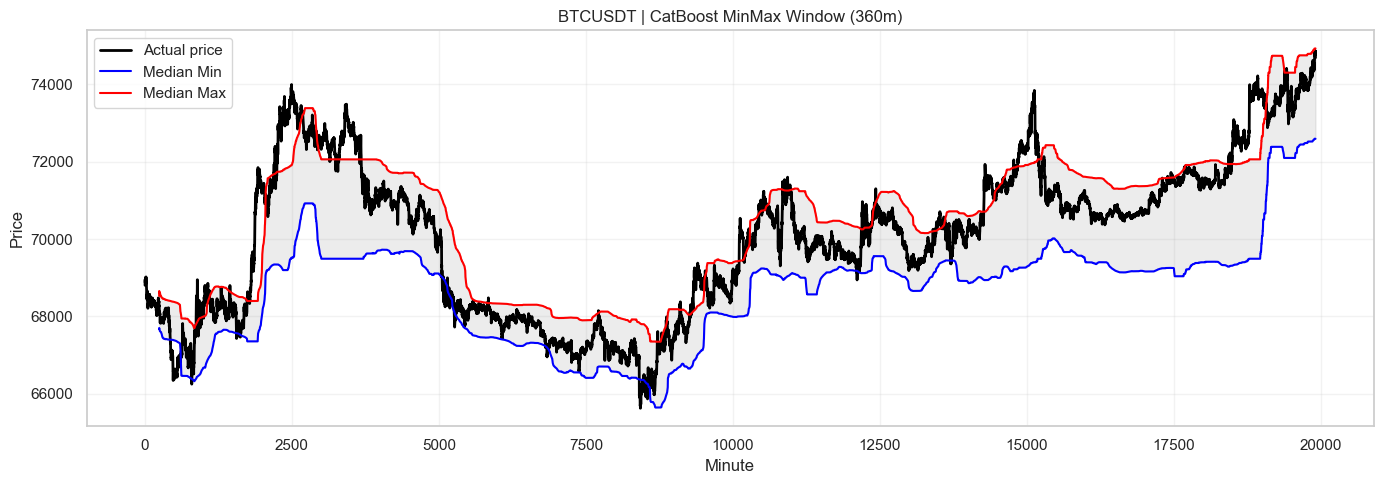

In [18]:
# CatBoost MinMax Window — объединённый компактный блок (заменяет 6 ячеек)
from model_baselines_catboost import fit_catboost_minmax_window_model, predict_catboost_minmax_window_path
import matplotlib.pyplot as plt

MINMAX_WINDOW = 360

# Базовый конфиг (по умолчанию используется best params из GridSearch)
minmax_base_cfg = {
    'context_len': int(catboost_best_params.get('context_len', 120)),
    'depth': int(catboost_best_params.get('depth', 8)),
    'learning_rate': float(catboost_best_params.get('learning_rate', 0.05)),
    'iterations': int(catboost_best_params.get('iterations', 600)),
    'l2_leaf_reg': float(catboost_best_params.get('l2_leaf_reg', 3.0)),
    'use_cuda': bool(CATBOOST_USE_CUDA),
}

# Опционально: отдельные параметры для min/max модели (включи, если нужен другой конфиг)
minmax_custom_cfg = {
    'context_len': 120,
    'depth': 8,
    'learning_rate': 0.05,
    'iterations': 600,
    'l2_leaf_reg': 3.0,
    'use_cuda': bool(CATBOOST_USE_CUDA),
}

# Включи, чтобы использовать отдельные параметры вместо best_params
USE_CUSTOM_MINMAX_CONFIG = False
PLOT_FULL_HISTORY = True

minmax_params = minmax_custom_cfg if USE_CUSTOM_MINMAX_CONFIG else minmax_base_cfg

if 'minmax_model' not in globals():
    minmax_model = fit_catboost_minmax_window_model(
        train_for_demo,
        window=MINMAX_WINDOW,
        **minmax_params,
    )

minmax_pred_df = predict_catboost_minmax_window_path(minmax_model, test_for_compare, window=MINMAX_WINDOW)
minmax_pred_df['median_min'] = minmax_pred_df['pred_min'].rolling(window=MINMAX_WINDOW, min_periods=1).median()
minmax_pred_df['median_max'] = minmax_pred_df['pred_max'].rolling(window=MINMAX_WINDOW, min_periods=1).median()

plt.figure(figsize=(14, 5))
plt.plot(test_for_compare.index, test_for_compare.values, label='Actual price', color='black', linewidth=2)
plt.plot(minmax_pred_df['minute'], minmax_pred_df['median_min'], label='Median Min', color='blue', linewidth=1.5)
plt.plot(minmax_pred_df['minute'], minmax_pred_df['median_max'], label='Median Max', color='red', linewidth=1.5)
plt.fill_between(minmax_pred_df['minute'], minmax_pred_df['median_min'], minmax_pred_df['median_max'], color='gray', alpha=0.15)
plt.title(f'{RUN_SYMBOL} | CatBoost MinMax Window ({MINMAX_WINDOW}m)')
plt.xlabel('Minute')
plt.ylabel('Price')
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

if PLOT_FULL_HISTORY and 'history_for_slider' in globals():
    minmax_slider_df = predict_catboost_minmax_window_path(minmax_model, history_for_slider['close'], window=MINMAX_WINDOW)
    n = min(len(history_for_slider), len(minmax_slider_df))
    ts = history_for_slider['timestamp'].iloc[:n]
    close = history_for_slider['close'].iloc[:n]
    pred_min = minmax_slider_df['pred_min'].iloc[:n]
    pred_max = minmax_slider_df['pred_max'].iloc[:n]
    plt.figure(figsize=(14, 5))
    plt.plot(ts, close, label='Actual price', color='black', linewidth=1.5)
    plt.plot(ts, pred_min, label='Predicted Min', color='blue', linewidth=1.2)
    plt.plot(ts, pred_max, label='Predicted Max', color='red', linewidth=1.2)
    plt.fill_between(ts, pred_min, pred_max, color='gray', alpha=0.15)
    plt.title('CatBoost MinMax Window (history)')
    plt.xlabel('timestamp')
    plt.ylabel('price')
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

In [19]:
# --- Backtest: (перенесено в конец) ---
import gc
import hashlib
import importlib
import json
import os
import pickle
from IPython.display import display

import catboost_backtest as _cb_backtest
import model_baselines_catboost as _mb
import torch

_cb_backtest = importlib.reload(_cb_backtest)
_mb = importlib.reload(_mb)

BacktestConfig = _cb_backtest.BacktestConfig
run_backtest_block = _cb_backtest.run_backtest_block
fit_catboost_multi_horizon_inference_model = _mb.fit_catboost_multi_horizon_inference_model
predict_catboost_multi_horizon_path = _mb.predict_catboost_multi_horizon_path

BACKTEST_ENABLED = True
BACKTEST_START_DAYS_AGO = 30
BACKTEST_DURATION_DAYS = 30
BACKTEST_TRAIN_MINUTES = 40_000
BACKTEST_RETRAIN_EVERY_HOURS = 168
BACKTEST_FORCE_CPU = False
BACKTEST_SAVE_TO_CSV = True
BACKTEST_DISPLAY_MAX_TRADES = 100
BACKTEST_EVAL_EVERY_MINUTES = 1
BACKTEST_PROGRESS_PLOTS_ENABLED = True

BACKTEST_QUICK_EXIT_ENABLED = True
BACKTEST_QUICK_EXIT_MINUTE = 500

BACKTEST_ENABLE_TRADE_EXECUTION = False

BACKTEST_INITIAL_CAPITAL = 1_000.0
BACKTEST_ENTRY_FRACTION = 0.25
BACKTEST_EXECUTION_FEE_PCT = float(LIVE_MAX_SIDE_FEE_PCT)

BACKTEST_MIN_60M_MOVE_PCT = 0.03
BACKTEST_COST_GATE_RATIO = 0.60
BACKTEST_LONG_ENTRY_SCORE_MIN = 0.42
BACKTEST_EXIT_SCORE_MAX = 0.08
BACKTEST_COOLDOWN_MINUTES = 20
BACKTEST_MIN_HOLD_MINUTES = 30
BACKTEST_TARGET_EXIT_MIN_HOLD_MINUTES = 45
BACKTEST_MAX_HOLD_MINUTES = 240
BACKTEST_TARGET_MOVE_FLOOR_PCT = 0.18
BACKTEST_SHARP_DROP_5M_PCT = 0.18
BACKTEST_SHARP_DROP_10M_PCT = 0.28

BACKTEST_ENTRY_POINT_C_HORIZON_MINUTES = 360
BACKTEST_ENTRY_POINT_C_MOVE_PCT = 0.001
BACKTEST_FORECAST_MODES = ['recursive', 'multi_horizon_direct']
BACKTEST_ANALYSIS_MODE = 'recursive'
BACKTEST_DIRECT_HORIZONS = [1, 5, 10, 15, 30, 60, 90, 120, 180, 240, 300, 360]

BACKTEST_USE_CACHE = False
BACKTEST_FORCE_RERUN = True
BACKTEST_CACHE_VERSION = 'v4'
BACKTEST_CUDA_ALLOWED = (bool(torch.cuda.is_available()) or os.getenv('CATBOOST_FORCE_GPU', '0').lower() in ('1', 'true', 'yes')) and (not BACKTEST_FORCE_CPU)

# Stability knobs for repeated GPU retrains inside walk-forward loop.
BACKTEST_ITER_SCALE = 0.50
BACKTEST_MIN_ITERATIONS = 200
BACKTEST_MAX_ITERATIONS = 600
BACKTEST_MAX_DEPTH = 10

BACKTEST_CACHE_FILE = os.path.join(str(OUTPUT_DIR), f"backtest_cache_{RUN_SYMBOL}.pkl")


def _build_backtest_config(forecast_mode: str) -> BacktestConfig:
    return BacktestConfig(
        enabled=bool(BACKTEST_ENABLED),
        start_days_ago=int(BACKTEST_START_DAYS_AGO),
        duration_days=int(BACKTEST_DURATION_DAYS),
        train_minutes=int(BACKTEST_TRAIN_MINUTES),
        retrain_every_hours=int(BACKTEST_RETRAIN_EVERY_HOURS),
        force_cpu=bool(BACKTEST_FORCE_CPU),
        save_to_csv=bool(BACKTEST_SAVE_TO_CSV),
        display_max_trades=int(BACKTEST_DISPLAY_MAX_TRADES),
        eval_every_minutes=int(BACKTEST_EVAL_EVERY_MINUTES),
        initial_capital=float(BACKTEST_INITIAL_CAPITAL),
        entry_fraction=float(BACKTEST_ENTRY_FRACTION),
        execution_fee_pct=float(BACKTEST_EXECUTION_FEE_PCT),
        min_60m_move_pct=float(BACKTEST_MIN_60M_MOVE_PCT),
        cost_gate_ratio=float(BACKTEST_COST_GATE_RATIO),
        long_entry_score_min=float(BACKTEST_LONG_ENTRY_SCORE_MIN),
        exit_score_max=float(BACKTEST_EXIT_SCORE_MAX),
        cooldown_minutes=int(BACKTEST_COOLDOWN_MINUTES),
        min_hold_minutes=int(BACKTEST_MIN_HOLD_MINUTES),
        target_exit_min_hold_minutes=int(BACKTEST_TARGET_EXIT_MIN_HOLD_MINUTES),
        max_hold_minutes=int(BACKTEST_MAX_HOLD_MINUTES),
        target_move_floor_pct=float(BACKTEST_TARGET_MOVE_FLOOR_PCT),
        sharp_drop_5m_pct=float(BACKTEST_SHARP_DROP_5M_PCT),
        sharp_drop_10m_pct=float(BACKTEST_SHARP_DROP_10M_PCT),
        live_confirm_1m_pct=float(LIVE_CONFIRM_1M_PCT),
        live_entry_min_move_pct=float(LIVE_ENTRY_MIN_MOVE_PCT),
        live_stop_loss_pct=float(LIVE_STOP_LOSS_PCT),
        live_take_profit_pct=float(LIVE_TAKE_PROFIT_PCT),
        live_forecast_horizon_minutes=int(LIVE_FORECAST_HORIZON_MINUTES),
        live_signal_horizons=tuple(int(horizon) for horizon in LIVE_SIGNAL_HORIZONS),
        entry_point_c_horizon_minutes=int(BACKTEST_ENTRY_POINT_C_HORIZON_MINUTES),
        entry_point_c_move_pct=float(BACKTEST_ENTRY_POINT_C_MOVE_PCT),
        forecast_mode=str(forecast_mode),
        quick_exit_enabled=bool(BACKTEST_QUICK_EXIT_ENABLED),
        quick_exit_minute=int(BACKTEST_QUICK_EXIT_MINUTE) if BACKTEST_QUICK_EXIT_ENABLED else None,
        enable_trade_execution=bool(BACKTEST_ENABLE_TRADE_EXECUTION),
    )


def _fit_backtest_multi_horizon_model(train_series, horizons, **kwargs):
    requested = {int(h) for h in BACKTEST_DIRECT_HORIZONS if int(h) > 0}
    requested.add(int(BACKTEST_ENTRY_POINT_C_HORIZON_MINUTES))
    requested.add(int(LIVE_FORECAST_HORIZON_MINUTES))
    safe_horizons = tuple(sorted(requested))
    return fit_catboost_multi_horizon_inference_model(
        train_series,
        horizons=safe_horizons,
        **kwargs,
    )


def _build_backtest_best_params(best_params: dict) -> dict:
    out = dict(best_params)
    base_iterations = int(out.get('iterations', 600))
    scaled_iterations = int(round(base_iterations * float(BACKTEST_ITER_SCALE)))
    out['iterations'] = int(max(BACKTEST_MIN_ITERATIONS, min(BACKTEST_MAX_ITERATIONS, scaled_iterations)))
    out['depth'] = int(min(int(out.get('depth', 8)), int(BACKTEST_MAX_DEPTH)))
    out['use_cuda'] = bool(BACKTEST_CUDA_ALLOWED)
    return out


def _maybe_release_memory() -> None:
    gc.collect()
    if torch.cuda.is_available():
        try:
            torch.cuda.empty_cache()
        except Exception:
            pass


def _ensure_mode_column(df, forecast_mode: str):
    if df is None or not hasattr(df, 'copy'):
        return df
    out = df.copy()
    if 'forecast_mode' not in out.columns:
        out['forecast_mode'] = str(forecast_mode)
    return out


def _bind_backtest_mode(selected_mode: str) -> None:
    if selected_mode not in BACKTEST_OUTPUTS_BY_MODE:
        raise KeyError(f'Unknown selected mode: {selected_mode}')
    selected_outputs = BACKTEST_OUTPUTS_BY_MODE[selected_mode]
    globals()['BACKTEST_SELECTED_MODE'] = str(selected_mode)
    globals()['history_df'] = selected_outputs['history_df']
    globals()['backtest_results'] = selected_outputs['backtest_results']
    globals()['backtest_meta_rows'] = selected_outputs['backtest_meta_rows']
    globals()['BACKTEST_FORECAST_HISTORY_DF'] = selected_outputs['backtest_forecast_history_df']
    globals()['BACKTEST_TRADES_DF'] = selected_outputs['backtest_trades_df']
    globals()['BACKTEST_META_DF'] = selected_outputs['backtest_meta_df']
    globals()['BACKTEST_TRADES_VIEW_DF'] = selected_outputs['backtest_trades_view_df']
    globals()['BACKTEST_DAILY_ACTIVITY_DF'] = selected_outputs['backtest_daily_activity_df']
    globals()['BACKTEST_TRADES_PATH'] = selected_outputs['backtest_trades_path']


backtest_best_params = _build_backtest_best_params(catboost_best_params)


def _build_backtest_cache_signature(history_df) -> str:
    history_sig = {
        'rows': int(len(history_df)),
        'start_ts': str(history_df['timestamp'].iloc[0]) if len(history_df) > 0 else None,
        'end_ts': str(history_df['timestamp'].iloc[-1]) if len(history_df) > 0 else None,
    }
    params_sig = {
        'symbol': str(RUN_SYMBOL),
        'cache_version': str(BACKTEST_CACHE_VERSION),
        'start_days_ago': int(BACKTEST_START_DAYS_AGO),
        'duration_days': int(BACKTEST_DURATION_DAYS),
        'train_minutes': int(BACKTEST_TRAIN_MINUTES),
        'retrain_every_hours': int(BACKTEST_RETRAIN_EVERY_HOURS),
        'eval_every_minutes': int(BACKTEST_EVAL_EVERY_MINUTES),
        'force_cpu': bool(BACKTEST_FORCE_CPU),
        'catboost_use_cuda': bool(BACKTEST_CUDA_ALLOWED),
        'forecast_modes': [str(m) for m in BACKTEST_FORECAST_MODES],
        'direct_horizons': [int(h) for h in BACKTEST_DIRECT_HORIZONS],
        'quick_exit_enabled': bool(BACKTEST_QUICK_EXIT_ENABLED),
        'quick_exit_minute': int(BACKTEST_QUICK_EXIT_MINUTE) if BACKTEST_QUICK_EXIT_ENABLED else None,
        'trade_execution': bool(BACKTEST_ENABLE_TRADE_EXECUTION),
        'best_params': {
            k: backtest_best_params[k]
            for k in sorted(backtest_best_params.keys())
            if k in ['context_len', 'depth', 'learning_rate', 'iterations', 'l2_leaf_reg', 'use_cuda']
        },
    }
    payload = {'history': history_sig, 'params': params_sig}
    return hashlib.sha256(json.dumps(payload, sort_keys=True, ensure_ascii=False).encode('utf-8')).hexdigest()


print(
    f'Backtest C-entry config: horizon={BACKTEST_ENTRY_POINT_C_HORIZON_MINUTES}m | '
    f'move_pct>={BACKTEST_ENTRY_POINT_C_MOVE_PCT:.3f}%'
)
print(
    f'Backtest forecast modes: {BACKTEST_FORECAST_MODES} | selected_for_analysis={BACKTEST_ANALYSIS_MODE}'
)
print(
    f'Backtest quick-exit: enabled={BACKTEST_QUICK_EXIT_ENABLED} | minute={BACKTEST_QUICK_EXIT_MINUTE}'
)
print(
    f'Backtest trade execution enabled: {BACKTEST_ENABLE_TRADE_EXECUTION}'
)
print(
    f'Backtest perf: eval_every={BACKTEST_EVAL_EVERY_MINUTES}m | cache_enabled={BACKTEST_USE_CACHE} | force_rerun={BACKTEST_FORCE_RERUN}'
)
print(
    f'Backtest CatBoost params (stability): iterations={backtest_best_params["iterations"]}, '
    f'depth={backtest_best_params["depth"]}, use_cuda={backtest_best_params["use_cuda"]}'
)
print(
    f'Backtest device: {"GPU" if BACKTEST_CUDA_ALLOWED else "CPU"}'
)

BACKTEST_OUTPUTS_BY_MODE = {}
summary_rows = []
history_for_backtest = cleaned_data[RUN_SYMBOL][['timestamp', 'close']].copy()
BACKTEST_CACHE_SIGNATURE = _build_backtest_cache_signature(history_for_backtest)

cache_loaded = False
if BACKTEST_USE_CACHE and (not BACKTEST_FORCE_RERUN) and os.path.exists(BACKTEST_CACHE_FILE):
    try:
        with open(BACKTEST_CACHE_FILE, 'rb') as f:
            cache_payload = pickle.load(f)
        if isinstance(cache_payload, dict) and 'signature' in cache_payload and 'outputs' in cache_payload:
            if cache_payload['signature'] == BACKTEST_CACHE_SIGNATURE:
                BACKTEST_OUTPUTS_BY_MODE = cache_payload['outputs']
                cache_loaded = True
                print(f'Загружены кэшированные результаты из {BACKTEST_CACHE_FILE}')
            else:
                print('Кэш найден, но подпись данных/параметров изменилась. Будет пересчет.')
        else:
            print('Кэш устаревшего формата. Будет пересчет и пересохранение.')
    except Exception as ex:
        print(f'Не удалось загрузить кэш ({ex}). Будет пересчет.')

if cache_loaded:
    summary_rows = [
        {
            'forecast_mode': mode,
            'forecast_rows': int(len(out['backtest_forecast_history_df'])),
            'trade_rows': int(len(out['backtest_trades_df'])),
            'meta_rows': int(len(out['backtest_meta_df'])),
            'trades_path': str(out['backtest_trades_path']) if out.get('backtest_trades_path') is not None else None,
        }
        for mode, out in BACKTEST_OUTPUTS_BY_MODE.items()
    ]
else:
    if not BACKTEST_ENABLED:
        print('Backtest disabled (BACKTEST_ENABLED=False).')
    else:
        for forecast_mode in BACKTEST_FORECAST_MODES:
            backtest_config = _build_backtest_config(forecast_mode)
            print(f'\n===== Running backtest mode: {forecast_mode} =====')
            backtest_outputs = run_backtest_block(
                history_df=history_for_backtest,
                run_symbol=RUN_SYMBOL,
                output_dir=OUTPUT_DIR,
                catboost_best_params=backtest_best_params,
                config=backtest_config,
                compute_signal_thresholds=_compute_signal_thresholds,
                fit_catboost_inference_model=fit_catboost_inference_model,
                fit_catboost_multi_horizon_model=_fit_backtest_multi_horizon_model,
                predict_catboost_multi_horizon_path=predict_catboost_multi_horizon_path,
                catboost_use_cuda=bool(BACKTEST_CUDA_ALLOWED),
                display_fn=display if BACKTEST_PROGRESS_PLOTS_ENABLED else None,
            )

            for key in [
                'backtest_forecast_history_df',
                'backtest_trades_df',
                'backtest_meta_df',
                'backtest_trades_view_df',
                'backtest_daily_activity_df',
            ]:
                backtest_outputs[key] = _ensure_mode_column(backtest_outputs.get(key), forecast_mode)

            BACKTEST_OUTPUTS_BY_MODE[forecast_mode] = backtest_outputs
            summary_rows.append({
                'forecast_mode': forecast_mode,
                'forecast_rows': int(len(backtest_outputs['backtest_forecast_history_df'])),
                'trade_rows': int(len(backtest_outputs['backtest_trades_df'])),
                'meta_rows': int(len(backtest_outputs['backtest_meta_df'])),
                'trades_path': str(backtest_outputs['backtest_trades_path']) if backtest_outputs.get('backtest_trades_path') is not None else None,
            })
            _maybe_release_memory()

        if BACKTEST_USE_CACHE:
            try:
                with open(BACKTEST_CACHE_FILE, 'wb') as f:
                    pickle.dump({'signature': BACKTEST_CACHE_SIGNATURE, 'outputs': BACKTEST_OUTPUTS_BY_MODE}, f)
                print(f'Backtest cache saved: {BACKTEST_CACHE_FILE}')
            except Exception as ex:
                print(f'Не удалось сохранить кэш backtest: {ex}')

BACKTEST_MODE_SUMMARY_DF = pd.DataFrame(summary_rows)
print('\nBacktest mode summary:')
display(BACKTEST_MODE_SUMMARY_DF)

BACKTEST_ALL_FORECAST_HISTORY_DF = pd.concat(
    [out['backtest_forecast_history_df'] for out in BACKTEST_OUTPUTS_BY_MODE.values() if len(out['backtest_forecast_history_df']) > 0],
    ignore_index=True,
) if any(len(out['backtest_forecast_history_df']) > 0 for out in BACKTEST_OUTPUTS_BY_MODE.values()) else pd.DataFrame()

BACKTEST_ALL_TRADES_DF = pd.concat(
    [out['backtest_trades_df'] for out in BACKTEST_OUTPUTS_BY_MODE.values() if len(out['backtest_trades_df']) > 0],
    ignore_index=True,
) if any(len(out['backtest_trades_df']) > 0 for out in BACKTEST_OUTPUTS_BY_MODE.values()) else pd.DataFrame()

BACKTEST_ALL_META_DF = pd.concat(
    [out['backtest_meta_df'] for out in BACKTEST_OUTPUTS_BY_MODE.values() if len(out['backtest_meta_df']) > 0],
    ignore_index=True,
) if any(len(out['backtest_meta_df']) > 0 for out in BACKTEST_OUTPUTS_BY_MODE.values()) else pd.DataFrame()

BACKTEST_ALL_TRADES_VIEW_DF = pd.concat(
    [out['backtest_trades_view_df'] for out in BACKTEST_OUTPUTS_BY_MODE.values() if len(out['backtest_trades_view_df']) > 0],
    ignore_index=True,
) if any(len(out['backtest_trades_view_df']) > 0 for out in BACKTEST_OUTPUTS_BY_MODE.values()) else pd.DataFrame()

BACKTEST_ALL_DAILY_ACTIVITY_DF = pd.concat(
    [out['backtest_daily_activity_df'] for out in BACKTEST_OUTPUTS_BY_MODE.values() if len(out['backtest_daily_activity_df']) > 0],
    ignore_index=True,
) if any(len(out['backtest_daily_activity_df']) > 0 for out in BACKTEST_OUTPUTS_BY_MODE.values()) else pd.DataFrame()

_bind_backtest_mode(BACKTEST_ANALYSIS_MODE)
print(f'\nSelected mode for downstream cells: {BACKTEST_SELECTED_MODE}')
print(f'Forecast history rows ({BACKTEST_SELECTED_MODE}): {len(BACKTEST_FORECAST_HISTORY_DF)}')
if len(BACKTEST_FORECAST_HISTORY_DF) > 0:
    display(BACKTEST_FORECAST_HISTORY_DF[['timestamp', 'current_price', 'forecast_horizon_minutes', 'forecast_mode']].tail(5))


Backtest C-entry config: horizon=360m | move_pct>=0.001%
Backtest forecast modes: ['recursive', 'multi_horizon_direct'] | selected_for_analysis=recursive
Backtest quick-exit: enabled=True | minute=500
Backtest trade execution enabled: False
Backtest perf: eval_every=1m | cache_enabled=False | force_rerun=True
Backtest CatBoost params (stability): iterations=300, depth=10, use_cuda=True
Backtest device: GPU

===== Running backtest mode: recursive =====
Backtest symbol=BTCUSDT | start_days_ago=30 | duration_days=30
Train minutes=40000 | retrain_every_hours=168 | eval_step_minutes=1
Mode=long_only | initial_capital=1000.00 | entry_fraction=0.25 | execution_fee_pct=0.0600
Scenario start | mode=long_only | capital=1000.00 | entry_fraction=0.25 | fee_pct=0.0600 | retrain_every=168h | forecast_mode=recursive | trade_execution=False | from=2026-02-14 22:21:00+00:00 | to=2026-03-16 22:21:00+00:00 | steps=43065
CatBoost: using GPU (task_type=GPU)
Retrained model | ts=2026-02-14 22:21:00+00:00 | 

,retrain_hours,requested_start_ts,requested_end_ts,actual_start_ts,actual_end_ts,effective_duration_days,eval_step_minutes,initial_capital,entry_fraction,execution_fee_pct,trade_actions,closed_trades,opened_longs,entry_c_checks,entry_c_hits,entry_c_hit_rate,entry_c_horizon_minutes,entry_c_move_pct,quick_exit_enabled,quick_exit_minute,trade_execution_enabled,ending_equity,ending_realized_pnl
0,168,2026-02-14 22:21:00+00:00,2026-03-16 22:21:00+00:00,2026-02-14 22:21:00+00:00,2026-03-16 22:21:00+00:00,30.0,1,1000.0,0.25,0.06,0,0,0,499,173,0.346693,360,0.001,True,500,False,1000.0,0.0



Trades: no trading actions were generated for the selected range.

===== Running backtest mode: multi_horizon_direct =====
INFO: forecast_mode=multi_horizon_direct uses direct horizon models with interpolated minute path.
Backtest symbol=BTCUSDT | start_days_ago=30 | duration_days=30
Train minutes=40000 | retrain_every_hours=168 | eval_step_minutes=1
Mode=long_only | initial_capital=1000.00 | entry_fraction=0.25 | execution_fee_pct=0.0600
Scenario start | mode=long_only | capital=1000.00 | entry_fraction=0.25 | fee_pct=0.0600 | retrain_every=168h | forecast_mode=multi_horizon_direct | trade_execution=False | from=2026-02-14 22:21:00+00:00 | to=2026-03-16 22:21:00+00:00 | steps=43065
CatBoost: using GPU (task_type=GPU)
CatBoost: using GPU (task_type=GPU)
CatBoost: using GPU (task_type=GPU)
CatBoost: using GPU (task_type=GPU)
CatBoost: using GPU (task_type=GPU)
CatBoost: using GPU (task_type=GPU)
CatBoost: using GPU (task_type=GPU)
CatBoost: using GPU (task_type=GPU)
CatBoost: using GPU

,retrain_hours,requested_start_ts,requested_end_ts,actual_start_ts,actual_end_ts,effective_duration_days,eval_step_minutes,initial_capital,entry_fraction,execution_fee_pct,trade_actions,closed_trades,opened_longs,entry_c_checks,entry_c_hits,entry_c_hit_rate,entry_c_horizon_minutes,entry_c_move_pct,quick_exit_enabled,quick_exit_minute,trade_execution_enabled,ending_equity,ending_realized_pnl
0,168,2026-02-14 22:21:00+00:00,2026-03-16 22:21:00+00:00,2026-02-14 22:21:00+00:00,2026-03-16 22:21:00+00:00,30.0,1,1000.0,0.25,0.06,0,0,0,499,135,0.270541,360,0.001,True,500,False,1000.0,0.0



Trades: no trading actions were generated for the selected range.

Backtest mode summary:


,forecast_mode,forecast_rows,trade_rows,meta_rows,trades_path
0,recursive,499,0,1,data\outputs\BTCUSDT_catboost_backtest_trades_...
1,multi_horizon_direct,499,0,1,data\outputs\BTCUSDT_catboost_backtest_trades_...



Selected mode for downstream cells: recursive
Forecast history rows (recursive): 499


,timestamp,current_price,forecast_horizon_minutes,forecast_mode
494,2026-02-15 06:36:00+00:00,70472.2,360,recursive
495,2026-02-15 06:37:00+00:00,70431.5,360,recursive
496,2026-02-15 06:38:00+00:00,70453.3,360,recursive
497,2026-02-15 06:39:00+00:00,70385.0,360,recursive
498,2026-02-15 06:40:00+00:00,70354.8,360,recursive


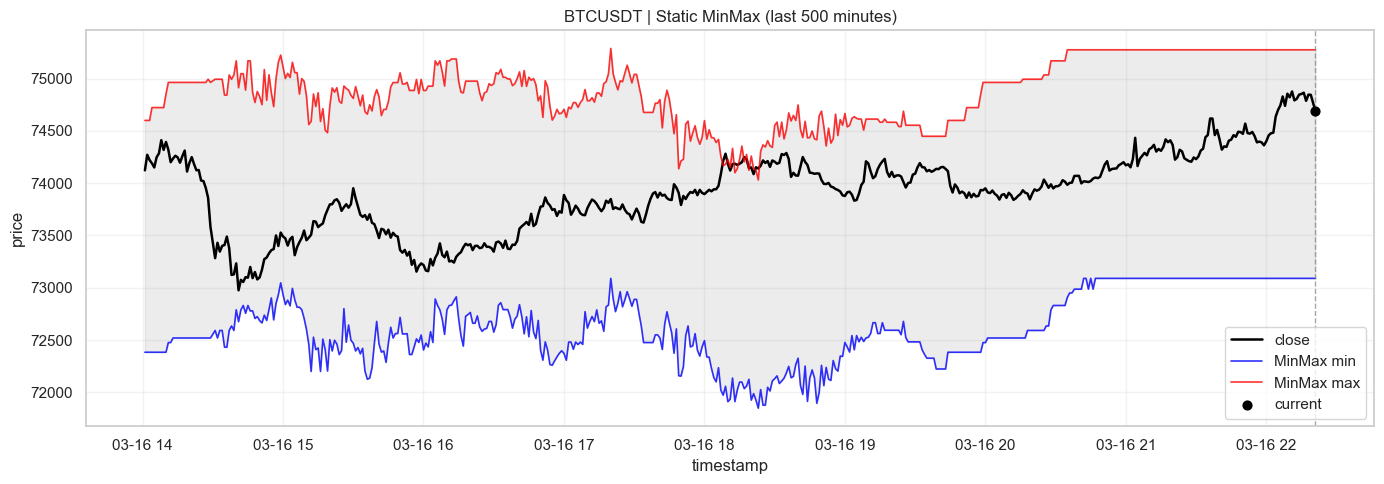

In [20]:
# Static MinMax chart (replaces the interactive viewer)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure backtest outputs are available
if 'BACKTEST_OUTPUTS_BY_MODE' not in globals() or len(BACKTEST_OUTPUTS_BY_MODE) == 0:
    raise RuntimeError('Сначала запустите backtest (последнюю ячейку).')

# Prepare history + minmax predictions (for overlay)
history_for_slider = cleaned_data[RUN_SYMBOL][['timestamp', 'close']].copy()
history_for_slider['timestamp'] = pd.to_datetime(history_for_slider['timestamp'], errors='coerce', utc=True)
history_for_slider['close'] = pd.to_numeric(history_for_slider['close'], errors='coerce')
history_for_slider = history_for_slider.dropna(subset=['timestamp', 'close'])
history_for_slider = history_for_slider.sort_values('timestamp').drop_duplicates(subset=['timestamp'], keep='last').reset_index(drop=True)

MINMAX_WINDOW = 360
minmax_slider_df = None

# Ensure we have a minmax model available for the plot (train on the fly if needed).
try:
    from model_baselines_catboost import fit_catboost_minmax_window_model, predict_catboost_minmax_window_path
except Exception:
    fit_catboost_minmax_window_model = None  # type: ignore
    predict_catboost_minmax_window_path = None  # type: ignore

if 'minmax_model' not in globals() and fit_catboost_minmax_window_model is not None:
    # Try to use the same params that were used in the main minmax block, if available.
    minmax_cfg = globals().get('minmax_params') or globals().get('minmax_base_cfg') or {}
    if isinstance(minmax_cfg, dict):
        try:
            minmax_model = fit_catboost_minmax_window_model(
                history_for_slider['close'],
                window=MINMAX_WINDOW,
                **minmax_cfg,
            )
            print('Trained minmax_model on the fly for static plot.')
        except Exception as ex:
            print(f'Could not train minmax_model automatically: {ex}')

if 'minmax_model' in globals() and predict_catboost_minmax_window_path is not None:
    try:
        minmax_slider_df = predict_catboost_minmax_window_path(
            minmax_model, history_for_slider['close'], window=MINMAX_WINDOW
        )
    except Exception as ex:
        print(f'Failed to compute minmax_slider_df: {ex}')

# Static min/max plot for the last N minutes
VIEW_WINDOW_MINUTES = 500
window_df = history_for_slider.tail(VIEW_WINDOW_MINUTES).copy()

plt.figure(figsize=(14, 5))
plt.plot(window_df['timestamp'], window_df['close'], color='black', linewidth=1.8, label='close')

if minmax_slider_df is not None and len(minmax_slider_df) > 0:
    n_plot = min(len(window_df), len(minmax_slider_df))
    window_minmax = minmax_slider_df.tail(n_plot).reset_index(drop=True)
    window_ts = window_df['timestamp'].tail(n_plot).reset_index(drop=True)

    plt.plot(window_ts, window_minmax['pred_min'], label='MinMax min', color='blue', linewidth=1.2, alpha=0.8)
    plt.plot(window_ts, window_minmax['pred_max'], label='MinMax max', color='red', linewidth=1.2, alpha=0.8)
    plt.fill_between(window_ts, window_minmax['pred_min'], window_minmax['pred_max'], color='gray', alpha=0.15)
else:
    print('MinMax prediction data is not available for plotting.')

last_ts = window_df['timestamp'].iloc[-1]
last_price = window_df['close'].iloc[-1]
plt.scatter([last_ts], [last_price], color='black', s=40, zorder=5, label='current')
plt.axvline(last_ts, color='gray', linestyle='--', linewidth=1.0, alpha=0.7)

plt.title(f'{RUN_SYMBOL} | Static MinMax (last {VIEW_WINDOW_MINUTES} minutes)')
plt.xlabel('timestamp')
plt.ylabel('price')
plt.grid(True, alpha=0.25)
plt.legend(loc='best')
plt.tight_layout()
plt.show()
